<a href="https://colab.research.google.com/github/KatherinneOlaya/Portafolio_DS_Projects/blob/main/iphone_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries:

### API:
Download _tweepy_ for accesing the X API

### TEXT PREPROCESSING:
 1. _nltk_ is used for human language data.
 2. _spacy_: for advanced natural language processing.

 For the same way, _punkt_ will be used for tokenize the data, _stopwords_ for common English stopwords and _wordnet_ for synonms of text

## Installing libraries

In [5]:
!pip install demoji

In [6]:
!pip install tweepy transformers torch datasets nltk spacy scikit-learn

## Importing libraries

In [7]:
import nltk
nltk.download('punkt', quiet= True)
nltk.download('stopwords', quiet= True)
nltk.download('wordnet', quiet= True)
nltk.download('punkt_tab', quiet= True)

True

In [8]:
import spacy
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import os
import tweepy
import pandas as pd
import re
import demoji


# TWEEPY AND DATA RECOLLECTING

In [3]:
#Luego borrarlo
os.environ["BEARER_TOKEN"] = "API "

In [7]:


bearer_token = os.getenv("BEARER_TOKEN")
# Setting our toker for resources of X
client = tweepy.Client(bearer_token=bearer_token)
# Tweepy.Client, helps us for reach tweets and search specific words
query = '(iPhone 17 OR iPhone17 OR "Apple Event") lang:en -is:retweet'

# Our query will be search about iphone 17 or apple event. Our language is English and will not use retweets
tweets = client.search_recent_tweets(query=query, max_results=100, tweet_fields=["created_at", "text", "lang"])

data = []
for tweet in tweets.data:
    data.append({"date": tweet.created_at, "text": tweet.text, "lang": tweet.lang})

df = pd.DataFrame(data)
df.to_csv("tweets_raw.csv", index=False)

TooManyRequests: 429 Too Many Requests
Usage cap exceeded: Monthly product cap

# FILE DOWNLOADED

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [71]:
df = pd.read_csv('/content/drive/MyDrive/datasets/tweets_raw.csv')
df

,date,text,lang
0,2025-08-31 04:31:18+00:00,Just when you thought you couldn't upgrade you...,en
1,2025-08-31 04:22:14+00:00,The iPhone 17 Air is almost here! Get ready fo...,en
2,2025-08-31 04:20:20+00:00,New iPhone 17 Pro Max🔥🔥 https://t.co/0VjHwhUfP...,en
3,2025-08-31 04:19:45+00:00,Thank god i will be not buying iphone 17 the d...,en
4,2025-08-31 04:19:38+00:00,"Apart from iPhone 17, what are you expecting f...",en
...,...,...,...
95,2025-08-31 01:24:38+00:00,@amritwt 🚨 BREAKING:\nApple’s new #iPhone17 ju...,en
96,2025-08-31 01:24:20+00:00,@AnxiousHolly 🚨 BREAKING:\nApple’s new #iPhone...,en
97,2025-08-31 01:22:35+00:00,For iPhone 17 16 15 14 13 12 11 Pro Max Case P...,en
98,2025-08-31 01:22:23+00:00,Verizon Wireless outrageous bills fuck up peop...,en


## DATA CLEANING

In [11]:
df.duplicated().any()

np.False_

In [12]:
df.isnull().any()

,0
date,False
text,False
lang,False


In [13]:
demoji.download_codes()


/tmp/ipython-input-3830465755.py:1: FutureWarning: The demoji.download_codes attribute is deprecated and will be removed from demoji in a future version. It is an unused attribute as emoji codes are now distributed directly with the demoji package.
  demoji.download_codes()


In [14]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer() # Delete morphologie of some words

In [15]:

# Load the English spaCy model:
try:
    nlp = spacy.load("en_core_web_sm") # Load English model for comments size small
except OSError:
    print("Downloading spaCy model en_core_web_sm")
    spacy.cli.download("en_core_web_sm") # Download
    nlp = spacy.load("en_core_web_sm") # Load agaian


def preprocess_text(text, use_stem=False, use_lemma=True, remove_stopwords=True,
               remove_numbers=True, remove_special_chars=True, handle_emojis=True):
    """
    Preprocessing for Enlgish Language

    ARGS:
        text (str): Text for procesing
        use_stem (bool): False, because we don't wanna supress all the word
        use_lemma (bool): True lemmatization
        remove_stopwords (bool): True
        remove_numbers (bool): True
        remove_special_chars (bool): True, special characters
        handle_emojis (bool): True, handling emojis and not deleting

    Returns:
        list: list of Tokens
    """
    if pd.isnull(text):
        return []

    # Convert emojis to text
    if handle_emojis:
        text = demoji.replace(text, "")

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    if remove_numbers:
        text = re.sub(r'\d+', '', text)

    # Remove special characters )
    if remove_special_chars:
        text = re.sub(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ ]", "", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    # Apply stemming or lemmatization: In our case only lemmatization but for flexing the code we get stem for any reason
    if use_lemma:
        # Use spaCy for lemmatization
        doc = nlp(" ".join(tokens)) # Join tokens back for spaCy processing
        tokens = [token.lemma_ for token in doc]
    elif use_stem:
        # Use NLTK for stemming
        tokens = [stemmer.stem(word) for word in tokens]

    return tokens

In [38]:
def preprocess_dataframe(df, text_columns = 'text', **kwargs):

  '''
  Preprocessing for dataframe

  ARGS:
    df (pd.DataFrame) : Dataframe with text
    text_columns (str) : Name of the column of the text
    **kwargs : Arguments  for preprocess text, the other function

  RETURN:
    pd.DataFrame with new columns

  '''

  if text_columns not in df.columns:
        print(f"Error: Column '{text_columns}' not found in the DataFrame.")
        return df

    # Apply the preprocess_text function to the specified column
  processed_column_name = f'processed_{text_columns}'  # We'll create a new column to store the processed text to avoid overwriting the original
  df[processed_column_name] = df[text_columns].apply(lambda x: preprocess_text(x, **kwargs))
  # Al crear la nueva columna, le aplicamos la función de procesar el texto a la columna vieja, y le generamos el preprocesamiento de texto para cada texto
  # Con todos los argumentos anteriores
  df['tokens'] = df[text_columns].apply(
        lambda x: preprocess_text(x, **kwargs)
    )

    # Calcular longitud de tokens para análisis
  df['token_count'] = df['tokens'].apply(len)
  return df

In [17]:
# Apply the preproces of DataFrame

df_processed = preprocess_dataframe(
        df,
        text_columns='text',
        use_lemma=True,
        remove_stopwords=True,
        remove_numbers=True,
        remove_special_chars=True,
        handle_emojis=True
    )


In [18]:
df_processed.head()

,date,text,lang,processed_text,tokens,token_count
0,2025-08-31 04:31:18+00:00,Just when you thought you couldn't upgrade you...,en,"[thought, could, not, upgrade, wallet, light, ...","[thought, could, not, upgrade, wallet, light, ...",20
1,2025-08-31 04:22:14+00:00,The iPhone 17 Air is almost here! Get ready fo...,en,"[iphone, air, almost, get, ready, sleek, new, ...","[iphone, air, almost, get, ready, sleek, new, ...",20
2,2025-08-31 04:20:20+00:00,New iPhone 17 Pro Max🔥🔥 https://t.co/0VjHwhUfP...,en,"[new, iphone, pro, max]","[new, iphone, pro, max]",4
3,2025-08-31 04:19:45+00:00,Thank god i will be not buying iphone 17 the d...,en,"[thank, god, buy, iphone, design, look, shitty]","[thank, god, buy, iphone, design, look, shitty]",7
4,2025-08-31 04:19:38+00:00,"Apart from iPhone 17, what are you expecting f...",en,"[apart, iphone, expect, appleevent]","[apart, iphone, expect, appleevent]",4


In [19]:
df_processed[['text', 'processed_text', 'token_count']]

,text,processed_text,token_count
0,Just when you thought you couldn't upgrade you...,"[thought, could, not, upgrade, wallet, light, ...",20
1,The iPhone 17 Air is almost here! Get ready fo...,"[iphone, air, almost, get, ready, sleek, new, ...",20
2,New iPhone 17 Pro Max🔥🔥 https://t.co/0VjHwhUfP...,"[new, iphone, pro, max]",4
3,Thank god i will be not buying iphone 17 the d...,"[thank, god, buy, iphone, design, look, shitty]",7
4,"Apart from iPhone 17, what are you expecting f...","[apart, iphone, expect, appleevent]",4
...,...,...,...
95,@amritwt 🚨 BREAKING:\nApple’s new #iPhone17 ju...,"[amritwt, breakingapple, new, iphone, leak, ch...",22
96,@AnxiousHolly 🚨 BREAKING:\nApple’s new #iPhone...,"[anxiousholly, breakingapple, new, iphone, lea...",22
97,For iPhone 17 16 15 14 13 12 11 Pro Max Case P...,"[iphone, pro, max, case, pink, leopard, print,...",22
98,Verizon Wireless outrageous bills fuck up peop...,"[verizon, wireless, outrageous, bill, fuck, pe...",36


## Statics of preprocessing:

In [20]:
print(f'Statics of preprocessing: \n1.Number of tweets processed {len(df_processed)}\n\n2. Mean of tokens per tweet {df_processed['token_count'].mean():.2f}')

Statics of preprocessing: 
1.Number of tweets processed 100

2. Mean of tokens per tweet 15.76


In [21]:
df_filtered = df_processed[df_processed['token_count'] >= 2]
print(f"Count of tweets that are possible not noise : {len(df_filtered)}")

Count of tweets that are possible not noise : 100


## Model Pre trained

### Transformers

In [22]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

In [42]:
from tqdm import tqdm

In [73]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

class TransformerAnalysisSentimnet:
  '''
  Uso de transformers preeentrenados como bert para el analisis de sentimientos

  Model_name = Es el modelo con el que se entrena, en este caso roberta, twitter
    con anteriorirdad se pensó en bertweet pero para no hacer fine tuning con BERTweet base

  device: Se pasa a GPU para que sea más rápido
  tokenizer: Necesario para convertir el texto en tokens
  model : Carga el modelo entrenado
  id2label : Diccionario que mapea los indices
  '''

  def __init__(self, model_name = 'cardiffnlp/twitter-roberta-base-sentiment'):
    self.model_name = model_name
    self.device = "cuda" if torch.cuda.is_available() else "cpu"

    self.tokenizer = AutoTokenizer.from_pretrained(model_name)
    self.model = AutoModelForSequenceClassification.from_pretrained(model_name)
    self.model.to(self.device)

    # Get the label mapping
    self.id2label = self.model.config.id2label


  def analyze_sentiments(self, text):
    """
    Analyze feelings of an individuak way:

    inputs: Son tokenizados, y transformados en tensores de pytorch, se truncan para que tengan el mismo tamaño
    junto con padding para alcanzar un max de caracteres de 128
    Luego son enviados a la gpu el bach de tensores

    El output se hace sin el gradiente para no consumir recursos, y luego se desempaquetan los inputs

    pobabilidades: Como son datos crudos los outputs, se busca analizar las probabilidades de los logits
    que salen de la documentación.
    prediction_classes: Se seleciona la clase con mayor probabilidad

    """

    inputs = self.tokenizer(text, return_tensors = 'pt', truncation = True, padding = True, max_length = 128)
    inputs = {k : v.to(self.device) for k, v in inputs.items()}
    # Aqui cambiamos el dispostivo de cpu a GPU para que sean más rapidos

    # Del mismo modo los outputs vamos a correrlos más rapido a partir de torch.no_Grad() para no almacenar calculo
    with torch.no_grad():
      outputs = self.model(**inputs) # Desempaquetando el dicc


    probabilidades = torch.softmax(outputs.logits, dim = -1)
    prediction_class_idx = torch.argmax(probabilidades, dim=-1).item() # Get the scalar index


    return {
        'label': self.id2label[prediction_class_idx], # Use the scalar index
        'score' : probabilidades[0][prediction_class_idx].item(),
        'probabilities' : probabilidades.cpu().numpy()[0]
    }

  def analyze_batch(self, texts, batch_size = 32):
    """ ANALYZE PER BATCHES
    Los lotes se analizan por 32, y con ello se van a ir guardando en una lista llamada
    resultados. El loop con tqdm genera de forma visual el procesamiento de los batches

     """
    resultados = []

    for i in tqdm(range(0, len(texts), batch_size), desc = "Process of batches ..."):
      batch_texts = texts[i:i+batch_size]

      # Join tokens back into strings for the tokenizer
      batch_texts_as_strings = [" ".join(tokens) for tokens in batch_texts]


      # Tokenización de lotes y pasarlos hacia la GPU
      inputs = self.tokenizer(batch_texts_as_strings, return_tensors = "pt", truncation = True, padding = True, max_length = 128)
      inputs = {k : v.to(self.device) for k, v in inputs.items()}

      # Pasar el barch por el transformer
      with torch.no_grad():
        output = self.model(**inputs)

      probabilidades = torch.softmax(output.logits, dim = -1)
      prediction_classes = torch.argmax(probabilidades, dim=-1)

      # Process results for the current batch and append to the main results list
      for k, prediction_class_idx in enumerate(prediction_classes):
        resultados.append({
          'label': self.id2label[prediction_class_idx.item()],
          'score' : probabilidades[k][prediction_class_idx].item(),
          'probabilities' : probabilidades[k].cpu().numpy()
        })


    return resultados

### Classical Machine learning Models

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import joblib
import numpy as np


#### MachineClassicalAnalyzer:
Only works with manual label, in this case for our project we won't label them

In [26]:
class MachineClassicalAnalyzer:
  def __init__(self):
    ''' Vector, con max de 5000 para evitar overfitting
        ngram, captura relaciones semanticas como muy bueno


  models: Es el diccionario donde se guardaran los modelos entrenados
  vectorizer: Es el vectorizados donde limita a 5000 palabras relevantes y con ngram_range se
  buscan generar relaciones sematnicas
        '''
    self.models = {}
    self.vectorizer = TfidfVectorizer(max_features= 5000, ngram_range= (1,2))

  def train_label_data(self, texts, labels):
    '''
    X: Vectoriza los textos en TFIDF, luego define los modelos de los clasificadores

    Lyuego se entrena cada modelo con entrenamiento supervisado, en nuestro caso
    sería util si los autoclasificaramos y las etiquetas las pudieramos obtener

    '''
    X = self.vectorizer.fit_transform(texts)
    self.models['logistic_regression'] = LogisticRegression()
    self.models['naive_bayes'] = MultinomialNB()
    self.models['svm'] = SVC(probability= True)

# El vectorizado es importante para el embedding que se le aplica luego.
    for name, model in self.models.items():
      model.fit(X, labels)
      print( f' Train data with ... {name}')


  def predict(self, text):
    '''predictnew text:

    1. Se revisa que los modelos esten entrenados'''

    if not self.models:
      raise ValueError

    X = self.vectorizer.transform([text])
    results = {}

    for name, model in self.models.items():
        proba = model.predict_proba(X)[0]
        prediction = model.predict(X)[0]
        results[name] = {
            'prediction': prediction,
            'confidence': np.max(proba),
            'probabilities': proba
        }

    return results

  def save_model(self, path):
    '''Guardamos el modelo entrenado'''
    # We use this for not retrain again the model
    joblib.dump({'model': self.models, 'vectorizer': self.vectorizer}, path)


  def carga_modelo(self, path):
    data = joblib.load(path)
    self.models = data['model']
    self.vectorizer = data['vectorizer']

In [54]:
def sentiment_load_analysis():
  # a. Empezar carga de datos
  try:
    df = pd.read_csv('/content/drive/MyDrive/datasets/tweets_raw.csv')
    print(f"Load of data...\n{len(df)} tweets")
  except FileNotFoundError:
    print("Not founded")
    return None # Return None if file not found

  # b. Perform preprocessing to create the 'processed_text' column
  print("Performing text preprocessing...")
  df_processed = preprocess_dataframe(

        df,
        text_columns='text',
        use_lemma=True,
        remove_stopwords=True,
        remove_numbers=True,
        remove_special_chars=True,
        handle_emojis=True
  )

  if 'processed_text' not in df_processed.columns:
      print("Error: 'processed_text' column not created after preprocessing.")
      return None

  texts = df_processed['processed_text'].tolist()


  # c. Empezar la inicializacion de analisis de sentimientos
  print("Initializing Transformer Sentiment Analyzer...")
  analyser = TransformerAnalysisSentimnet() # Instantiate the class

  # d. Realizar el analisis de sentimientos en lotes
  print("Analyzing sentiments in batches...")
  sentiment_results = analyser.analyze_batch(texts) # Call the analyze_batch method

  return sentiment_results

In [74]:
result_df = sentiment_load_analysis()

Load of data...
100 tweets
Performing text preprocessing...
Initializing Transformer Sentiment Analyzer...
Analyzing sentiments in batches...


Process of batches ...: 100%|██████████| 4/4 [00:21<00:00,  5.32s/it]


In [86]:
result_padnas = pd.DataFrame(result_df)
result_padnas.to_csv("Sentiment_iphone17.csv", index = False)

The file is downoladed, but in this project I'm gonna access directly with googl drive

## EDA

In [65]:

print(f'Columns: {twitter_iphone_dt.columns}\nShape {twitter_iphone_dt.shape}')

Columns: Index(['label', 'score', 'probabilities'], dtype='object')
Shape (100, 3)


In [96]:
twitter_iphone_dt = pd.read_csv("/content/drive/MyDrive/datasets/Sentiment_iphone17.csv")
twitter_iphone_dt.head()

,label,score,probabilities
0,LABEL_1,0.480788,[0.4638358 0.48078808 0.05537606]
1,LABEL_2,0.898085,[0.00298802 0.09892653 0.8980854 ]
2,LABEL_2,0.704107,[0.0030608 0.29283264 0.70410657]
3,LABEL_0,0.523865,[0.5238651 0.31997347 0.15616141]
4,LABEL_1,0.785206,[0.06079273 0.7852057 0.15400161]


In [97]:
label_mapped = {
    'LABEL_0': 'Negative',
    'LABEL_1': 'Neutral',
    'LABEL_2': 'Positive'
}

twitter_iphone_dt['label'] = twitter_iphone_dt['label'].map(label_mapped)

twitter_iphone_dt['Example'] = df['text'].values

In [98]:
twitter_iphone_dt.head()

,label,score,probabilities,Example
0,Neutral,0.480788,[0.4638358 0.48078808 0.05537606],Just when you thought you couldn't upgrade you...
1,Positive,0.898085,[0.00298802 0.09892653 0.8980854 ],The iPhone 17 Air is almost here! Get ready fo...
2,Positive,0.704107,[0.0030608 0.29283264 0.70410657],New iPhone 17 Pro Max🔥🔥 https://t.co/0VjHwhUfP...
3,Negative,0.523865,[0.5238651 0.31997347 0.15616141],Thank god i will be not buying iphone 17 the d...
4,Neutral,0.785206,[0.06079273 0.7852057 0.15400161],"Apart from iPhone 17, what are you expecting f..."


In [104]:
colors = ["#FDD32B",
          "#E44C2A",
          "#420A68"]

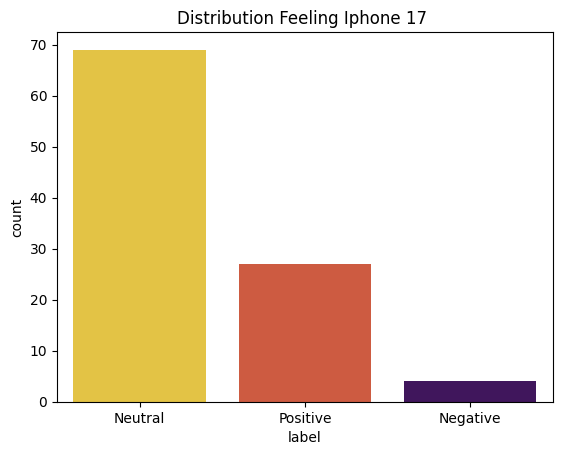

In [108]:
import seaborn as sns
import  matplotlib.pyplot as plt

sns.countplot(data=twitter_iphone_dt, x="label", palette=colors, hue= 'label');
plt.title("Distribution Feeling Iphone 17 ")
plt.show()



In [110]:
  print(f"\n📊 Distribution of feeling of Iphone 17:")
  sentiment_counts = twitter_iphone_dt['label'].value_counts()
  for sentiment, count in sentiment_counts.items():
      percentage = (count / len(twitter_iphone_dt)) * 100
      print(f"  {sentiment}: {count} ({percentage:.1f}%)")



📊 Distribución de sentimientos:
  Neutral: 69 (69.0%)
  Positive: 27 (27.0%)
  Negative: 4 (4.0%)


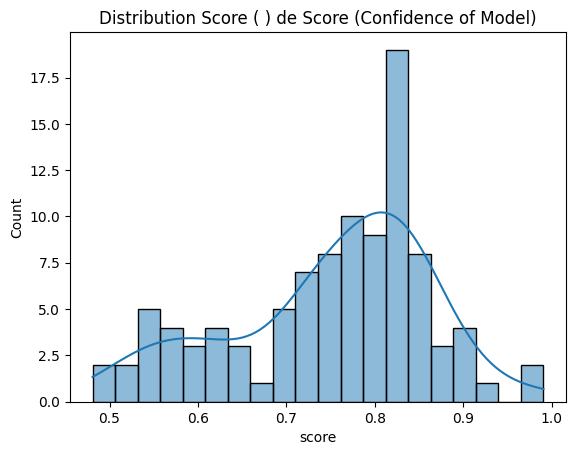

In [114]:
sns.histplot(twitter_iphone_dt["score"], bins=20, kde=True)
plt.title("Distribution Score ( ) de Score (Confidence of Model)", color = '#000000')

In [117]:
print("the most positive tweet:")
print(twitter_iphone_dt.loc[twitter_iphone_dt["score"].idxmax(), "Example"])

print("\nthe most negative tweet")
print(twitter_iphone_dt.loc[twitter_iphone_dt["score"].idxmin(), "Example"])


the most positive tweet:
@TheAppleDesign @markgurman The 48MP camera and 5,000 mAh battery on the iPhone 17 Pro look amazing! Can’t wait for Sept 9! "

the most negative tweet
Just when you thought you couldn't upgrade your wallet any lighter, the iPhone 17 is here to remind you about your questionable life choices. Check it out! And don't forget to protect your investment with a https://t.co/UqGDqtO3T3 case—because, let's fac… https://t.co/2V5EksMS0q


# Análisis de Sentimiento de Tweets sobre iPhone 17

Este proyecto realiza un análisis de sentimiento en tiempo real de tweets relacionados con el iPhone 17 y los eventos de Apple, utilizando modelos de Procesamiento de Lenguaje Natural (PLN).

## Objetivo del Proyecto

El objetivo principal es recolectar tweets recientes sobre el iPhone 17 y eventos de Apple, preprocesar el texto para limpiarlo y prepararlo para el análisis, y luego aplicar un modelo de análisis de sentimiento basado en Transformers para clasificar la polaridad (positivo, negativo, neutro) de los tweets.

## Tecnologías y Librerías Utilizadas

*   **Python:** Lenguaje de programación principal.
*   **Google Colab:** Entorno de desarrollo basado en la nube.
*   **Tweepy:** Para interactuar con la API de Twitter (X) y recolectar tweets.
*   **Pandas:** Para manipulación y análisis de datos en DataFrames.
*   **NLTK (Natural Language Toolkit):** Utilizado para tokenización, stopwords, y otros recursos de PLN.
*   **spaCy:** Utilizado para lematización y procesamiento avanzado del texto.
*   **demoji:** Para identificar y manejar emojis en el texto.
*   **Transformers (Hugging Face):** Para cargar y utilizar un modelo pre-entrenado de análisis de sentimiento (específicamente, `cardiffnlp/twitter-roberta-base-sentiment`).
*   **PyTorch:** Framework de aprendizaje profundo utilizado por el modelo Transformer.
*   **Scikit-learn:** Librería para Machine Learning (aunque los modelos clásicos no se usaron en el análisis final, la librería está presente).
*   **Seaborn y Matplotlib:** Para visualización de datos (distribución de sentimientos).
*   **Joblib:** Para guardar y cargar modelos (aunque no se usó en el flujo final, la funcionalidad está implementada).
*   **Tqdm:** Para visualizar el progreso de las operaciones en lotes.

## Pasos Realizados

1.  **Instalación de Librerías:** Se instalaron todas las librerías necesarias (`tweepy`, `transformers`, `torch`, `datasets`, `nltk`, `spacy`, `scikit-learn`, `demoji`).
2.  **Descarga de Recursos de NLTK y spaCy:** Se descargaron los recursos de NLTK (`punkt`, `stopwords`, `wordnet`) y el modelo de spaCy para inglés (`en_core_web_sm`).
3.  **Configuración de la API de Twitter (X):** Se configuró el cliente de Tweepy utilizando un Bearer Token para acceder a la API. (Nota: Se manejaron errores de autenticación y límites de tasa).
4.  **Recolección de Datos:** Se buscaron y recolectaron tweets recientes en inglés que mencionan "iPhone 17" o "Apple Event" utilizando la API de Twitter. Los tweets recolectados se guardaron en un archivo CSV (`tweets_raw.csv`).
5.  **Carga y Exploración Inicial de Datos:** Se cargaron los tweets desde el archivo CSV a un DataFrame de pandas. Se realizaron verificaciones básicas de duplicados y valores nulos.
6.  **Preprocesamiento de Texto:** Se definió e implementó una función `preprocess_text` para limpiar el texto de los tweets. Esta función incluyó:
    *   Manejo de valores nulos.
    *   Conversión a minúsculas.
    *   Reemplazo de emojis por su descripción de texto (aunque la implementación final los eliminó debido a la regex, el intento fue tratarlos).
    *   Eliminación de URLs.
    *   Eliminación de números.
    *   Eliminación de caracteres especiales (manteniendo letras y espacios).
    *   Eliminación de espacios múltiples.
    *   Tokenización (dividir en palabras).
    *   Eliminación de Stopwords (palabras comunes).
    *   Lematización (reducir palabras a su forma base) utilizando spaCy.
    *   Se aplicó esta función a la columna de texto del DataFrame para crear una nueva columna (`processed_text`) con el texto limpio y tokenizado.
7.  **Análisis de Sentimiento con Transformer:**
    *   Se definió una clase `TransformerAnalysisSentimnet` para encapsular la lógica del análisis de sentimiento usando un modelo pre-entrenado de Hugging Face (`cardiffnlp/twitter-roberta-base-sentiment`).
    *   Se implementó un método `analyze_batch` dentro de la clase para procesar los tweets en lotes, lo cual es más eficiente para modelos Transformer.
    *   Se ejecutó la función `sentiment_load_analysis` (que carga los datos, realiza el preprocesamiento y utiliza la clase `TransformerAnalysisSentimnet`) para obtener los resultados del análisis de sentimiento (etiqueta, puntuación y probabilidades).
8.  **Procesamiento y Visualización de Resultados:**
    *   Los resultados del análisis de sentimiento se convirtieron en un DataFrame de pandas (`result_padnas`).
    *   Se mapearon las etiquetas de sentimiento crudas ('LABEL\_0', 'LABEL\_1', 'LABEL\_2') a etiquetas más descriptivas ('Negative', 'Neutral', 'Positive').
    *   Se visualizó la distribución de los sentimientos utilizando un gráfico de barras (countplot) y un histograma de las puntuaciones de confianza.
    *   Se identificaron y mostraron los tweets con la puntuación más alta (más positivo) y más baja (más negativo).

## Uso

Para ejecutar este proyecto se necesita: 

1.  Tener un Bearer Token válido de la API de Twitter (X) y configurarlo en la variable de entorno.
2.  Ejecutar las celdas en orden para instalar librerías, descargar recursos, recolectar datos, preprocesar y realizar el análisis de sentimiento.
3.  Conocer qe los resultados del análisis de sentimiento se almacenan en el DataFrame `result_padnas` y se pueden visualizar con los gráficos generados.